In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Binomial Distribution

[Text(0.5, 1.0, 'Binomial Distribution with n=30,p=0.5')]

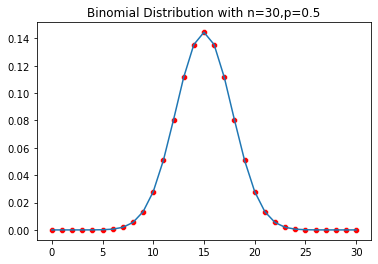

In [5]:
x_range = list(range(30+1))
pvalue_list = stats.binom.pmf(x_range,30,0.5)
ax = sns.scatterplot(x=x_range,y=pvalue_list,color='red')
ax = sns.lineplot(x=x_range,y=pvalue_list)
ax.set(title="Binomial Distribution with n=30,p=0.5")

[Text(0.5, 1.0, 'Binomial Distribution with n=30,p=0.1')]

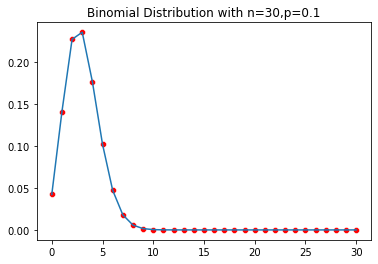

In [6]:
x_range = list(range(30+1))
pvalue_list = stats.binom.pmf(x_range,30,0.1)
ax = sns.scatterplot(x=x_range,y=pvalue_list,color='red')
ax = sns.lineplot(x=x_range,y=pvalue_list)
ax.set(title="Binomial Distribution with n=30,p=0.1")

[Text(0.5, 1.0, 'Binomial Distribution with n=30,p=0.99')]

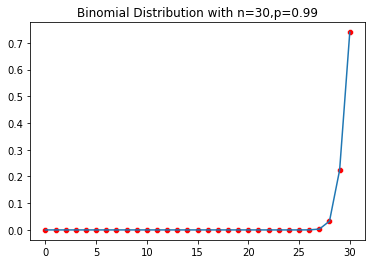

In [7]:
x_range = list(range(30+1))
pvalue_list = stats.binom.pmf(x_range,30,0.99)
ax = sns.scatterplot(x=x_range,y=pvalue_list,color='red')
ax = sns.lineplot(x=x_range,y=pvalue_list)
ax.set(title="Binomial Distribution with n=30,p=0.99")

# Monte Carlo Simulation

In [33]:
check_pvalue = 0.001
random_x = stats.binom.rvs(30,0.5,size=1000000)
sim_pvalue_list = stats.binom.pmf(random_x,30,0.5)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

0.001403

In [34]:
sim_pvalue_list = stats.binom.pmf(random_x,30,0.1)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

0.978628

In [35]:
sim_pvalue_list = stats.binom.pmf(random_x,30,0.99)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

0.999997

# Multinomial Distribution

In [39]:
stats.multinomial.pmf((1,1,1),3,[1/3,1/3,1/3])

0.2222222222222222

In [51]:
p_profile = [0.1,0.3,0.2,0.2,0.1,0.1]
exp_profile = {
    5:[0,3,0,1,1,0],
    6:[5,0,0,0,0,1],
    4:[0,0,2,1,1,0],
}

for k,v in exp_profile.items():
    bar_p = stats.multinomial.pmf(v,k,p_profile)
    print(bar_p)


0.010799999999999983
6.00000000000001e-06
0.009600000000000008


In [41]:
check_pvalue = 0.0107
random_x = stats.multinomial.rvs(5,p_profile,size=1000000)
sim_pvalue_list = stats.multinomial.pmf(random_x,5,p_profile)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

0.509838

In [53]:
check_pvalue = 6e-6
random_x = stats.multinomial.rvs(6,p_profile,size=1000000)
sim_pvalue_list = stats.multinomial.pmf(random_x,6,p_profile)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

1.8e-05

In [54]:
check_pvalue = 0.0096
random_x = stats.multinomial.rvs(4,p_profile,size=1000000)
sim_pvalue_list = stats.multinomial.pmf(random_x,4,p_profile)
(check_pvalue > sim_pvalue_list).sum() / len(sim_pvalue_list)

0.24403

# Good-Turing smoothing

In [32]:
from simple_good_turing import Estimator
from simple_good_turing.sgt import ChinesePluralsTest,ProsodyTest
from collections import defaultdict

In [27]:
cpt = ChinesePluralsTest()
N = cpt.input
print(N)


defaultdict(<function ChinesePluralsTest.<lambda> at 0x000001C24C5EBD00>, {1: 268, 2: 112, 3: 70, 4: 41, 5: 24, 6: 14, 7: 15, 8: 14, 9: 8, 10: 11, 11: 9, 12: 6, 13: 6, 14: 3, 15: 7, 16: 9, 17: 4, 18: 4, 19: 8, 20: 2, 21: 4, 22: 2, 23: 2, 24: 3, 25: 4, 26: 4, 27: 4, 28: 1, 29: 1, 31: 2, 33: 1, 39: 3, 41: 1, 46: 1, 47: 1, 50: 1, 52: 2, 53: 1, 55: 1, 57: 1, 60: 1, 74: 1, 84: 1, 108: 1, 109: 1, 177: 1, 400: 1, 1918: 1})


In [5]:
est = Estimator(N)
print(dir(est))

['N', 'Z', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_cache_rstar_unnorm', '_find_cutoff', '_find_norm_constant', '_precompute', '_regress', 'a', 'approx_turing_variance', 'b', 'linear_cutoff', 'linear_rstar_unnorm', 'max_r', 'norm_constant', 'p', 'p_unnorm', 'rstar', 'rstar_unnorm', 'turing_rstar_unnorm', 'x', 'y']


In [13]:
est.rstar(1)

0.8414892863926515

In [12]:
est.p(1)

0.0001284520357796751

In [14]:
est.p(0)

6.244815259606874e-06

In [19]:
r_list = list(N.keys())
r_list = [0] + r_list
p_total = 0
for r in r_list:
    rstar = est.rstar(r)
    p = est.p(r)
    print(f"{r:<10}{rstar:<30}{p:<30}")
    p_total += p

print(f"total p value summary: {p_total}")

0         0.04090978476568463           6.244815259606874e-06         
1         0.8414892863926515            0.0001284520357796751         
2         1.8877159214835153            0.0002881569106218158         
3         2.2884524359613714            0.0003493287186630089         
4         3.2472585599065322            0.0004956889879265047         
5         4.222093875085064             0.0006444960883964378         
6         5.206074432318033             0.0007946991958965094         
7         6.19576475351872              0.0009457738900196489         
8         7.189258694383636             0.001097429200791274          
9         8.185413639264436             0.0012494907097030125         
10        9.183502988156892             0.0014018475023900004         
11        10.183042613755688            0.0015544256775691784         
12        11.183697503750986            0.0017071740961305123         
13        12.185228453779393            0.0018600562438985488         
14    

In [22]:
class Test_Prosody():
    data = (
        (1, 120),
        (2, 40),
        (3, 24),
        (4, 13),
        (5, 15),
        (6, 5),
        (7, 11),
        (8, 2),
        (9, 2),
        (10, 1),
        (12, 3),
        (14, 2),
        (15, 1),
        (16, 1),
        (17, 3),
        (19, 1),
        (20, 3),
        (21, 2),
        (23, 3),
        (24, 3),
        (25, 3),
        (26, 2),
        (27, 2),
        (28, 1),
        (31, 2),
        (32, 2),
        (33, 1),
        (34, 2),
        (36, 2),
        (41, 3),
        (43, 1),
        (45, 3),
        (46, 1),
        (47, 1),
        (50, 1),
        (71, 1),
        (84, 1),
        (101, 1),
        (105, 1),
        (121, 1),
        (124, 1),
        (146, 1),
        (162, 1),
        (193, 1),
        (199, 1),
        (224, 1),
        (226, 1),
        (254, 1),
        (257, 1),
        (339, 1),
        (421, 1),
        (456, 1),
        (481, 1),
        (483, 1),
        (1140, 1),
        (1256, 1),
        (1322, 1),
        (1530, 1),
        (2131, 1),
        (2395, 1),
        (6925, 1),
        (7846, 1),
    )

    # Computed using R 3.5.1 w/ the Gale S code
    expect_p0 = 0.003883244
    expect_rstar = np.array((
        0.7628079,
        1.706448,
        2.679796,
        3.663988,
        4.653366,
        5.645628,
        6.63966,
        7.634856,
        8.63086,
        9.627446,
        11.62182,
        13.61725,
        14.61524,
        15.61336,
        16.6116,
        18.60836,
        19.60685,
        20.6054,
        22.60264,
        23.60133,
        24.60005,
        25.5988,
        26.59759,
        27.59639,
        30.59294,
        31.59183,
        32.59073,
        33.58964,
        35.58751,
        40.58235,
        42.58035,
        44.57836,
        45.57738,
        46.57641,
        49.57351,
        70.55399,
        83.54229,
        100.5272,
        104.5237,
        120.5097,
        123.507,
        145.4879,
        161.474,
        192.4472,
        198.4421,
        223.4205,
        225.4188,
        253.3947,
        256.3922,
        338.3218,
        420.2514,
        455.2215,
        480.2,
        482.1983,
        1138.636,
        1254.537,
        1320.48,
        1528.302,
        2128.788,
        2392.562,
        6918.687,
        7838.899,
    ))


In [34]:
test_prosody = Test_Prosody()
prosody_N = defaultdict(lambda:0)
prosody_N.update(dict(test_prosody.data))
est = Estimator(prosody_N)

In [43]:
total_count = sum(prosody_N[r] * r for r in range(1, max(prosody_N.keys()) + 1))
total_count

30902

In [44]:
0.7628078741437085 / total_count

2.4684741251171723e-05

In [54]:
p_total = 0
total_count = 0
r0 = est.rstar(0)
print(r0)
for r,freq in prosody_N.items():
    rstar = est.rstar(r)
    total_count += rstar * freq
    if freq != 0:
        p = est.p(r)
        print(f"{r:<10}{rstar:<30}{p:<30}")

print(f"total_count is {total_count}")

0.003883243802990098
1         0.7628078741437085            2.4684741251171723e-05        
2         1.7064478291506475            5.522127464729298e-05         
3         2.679795902612648             8.671917360082352e-05         
4         3.663988499384537             0.00011856800528718326        
5         4.6533661846914836            0.00015058462833122399        
6         5.645627899033096             0.00018269457960756895        
7         6.639659681617268             0.0002148618109383622         
8         7.634856147445485             0.0002470667318440711         
9         8.630859848282887             0.00027929777516933813        
10        9.627446084723713             0.000311547669559372          
12        11.621819175611188            0.0003760863107763636         
14        13.617251610218606            0.0004406592327428194         
15        14.61523923798975             0.0004729544766678451         
16        15.613364686856446            0.00050525418053

In [56]:
total_p = r0
pstar_list = []
for r,freq in prosody_N.items():
    if freq != 0:
        rstar = est.rstar(r)
        pstar = (1 - r0) * (rstar / total_count) 
        pstar_list.append(pstar)
        print(r,rstar,pstar)
        total_p += pstar * freq
print(total_p)

1 0.7628078741437085 2.468474125117172e-05
2 1.7064478291506475 5.522127464729298e-05
3 2.679795902612648 8.671917360082352e-05
4 3.663988499384537 0.00011856800528718326
5 4.6533661846914836 0.00015058462833122399
6 5.645627899033096 0.00018269457960756895
7 6.639659681617268 0.00021486181093836217
8 7.634856147445485 0.0002470667318440711
9 8.630859848282887 0.00027929777516933813
10 9.627446084723713 0.000311547669559372
12 11.621819175611188 0.0003760863107763636
14 13.617251610218606 0.0004406592327428194
15 14.61523923798975 0.0004729544766678451
16 15.613364686856446 0.0005052541805338311
17 16.611604710369246 0.0005375575920771874
19 18.608358995923346 0.0006021732896227865
20 19.606846873001437 0.0006344847217979884
21 20.605395020053255 0.0006667981043315402
23 22.602641721400964 0.0007314297366319644
24 23.60132814075676 0.0007637475937077457
25 24.600050084524185 0.0007960666003664548
26 25.598803574588157 0.0008283866278748351
27 26.59758520546412 0.0008607075660301638
28 